# ML Classification Notebook

Hier vergleichen wir unterschiedliche ML Modelle um daraus das beste herauszunehmen und anschliessend dieses auf unsere Daten zu Trainiren.



## 1. Bibliotheken Import

In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, ConfusionMatrixDisplay, make_scorer
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import loguniform, randint
import matplotlib.pyplot as plt
import json

## 2. Daten einlesen

In [3]:
train_data = np.load("../../../Model_data/Daten_WS50/train_WS50.npz")
X_train_raw = train_data["X"]
y_train_raw = train_data["y"]

test_data = np.load("../../../Model_data/Daten_WS50/test_WS50.npz")
X_test_raw = test_data["X"]
y_test_raw = test_data["y"]

CHANNEL_NAMES = [
    "x_acc", "y_acc", "z_acc",
    "x_gyr", "y_gyr", "z_gyr",
    "qx", "qy", "qz", "qw",
    "roll", "pitch", "yaw"
]

print(f"X_train: {X_train_raw.shape}  y_train: {y_train_raw.shape}")
print(f"X_test:  {X_test_raw.shape}  y_test:  {y_test_raw.shape}")
print(f"Klassen: {np.unique(y_train_raw)}")

X_train: (34451, 50, 13)  y_train: (34451,)
X_test:  (8447, 50, 13)  y_test:  (8447,)
Klassen: ['Auto' 'Laufen' 'Lift' 'Roundkick' 'Treppe' 'Velo' 'Zug']


### Erklärung des Outputs
Wir kopieren hier den Output und schreiben anstelle der Zahlen ihre bedeutung.

X_train: (Anz. Sliding Windows, Zeitschritte/Fenster, Anz. Sensorkanäle pro Zeitschritt)  y_train: (Anz. Sliding Windows,)

X_test:  (Anz. Sliding Windows, Zeitschritte/Fenster, Anz. Sensorkanäle pro Zeitschritt)  y_test:  (Anz. Sliding Windows,)

## 3. Klassenverteilung anschauen
Hier können wir erkennen wie die Klassen in den Trainingsdatensätzen verteilt ist.

In [4]:
klassen_train, klassenverteilung_train = np.unique(y_train_raw, return_counts=True)
klassen_test, klassenverteilung_test = np.unique(y_test_raw, return_counts=True)

print("Aufteilung im Trainingsset:\n")
for klasse, anzahl in zip(klassen_train, klassenverteilung_train):
    prozent = anzahl / len(y_train_raw) * 100
    print(f"Klasse {klasse}: {anzahl} ({prozent:.2f}%)")

print("\nAufteilung im Testset:\n")

for klasse, anzahl in zip(klassen_test, klassenverteilung_test):
    prozent = anzahl / len(y_test_raw) * 100
    print(f"Klasse {klasse}: {anzahl} ({prozent:.2f}%)")

Aufteilung im Trainingsset:

Klasse Auto: 7415 (21.52%)
Klasse Laufen: 7083 (20.56%)
Klasse Lift: 1965 (5.70%)
Klasse Roundkick: 863 (2.51%)
Klasse Treppe: 1235 (3.58%)
Klasse Velo: 8837 (25.65%)
Klasse Zug: 7053 (20.47%)

Aufteilung im Testset:

Klasse Auto: 1611 (19.07%)
Klasse Laufen: 1632 (19.32%)
Klasse Lift: 443 (5.24%)
Klasse Roundkick: 195 (2.31%)
Klasse Treppe: 320 (3.79%)
Klasse Velo: 2350 (27.82%)
Klasse Zug: 1896 (22.45%)


## 4. Feature Engineering
Aktuell hat jedes Fenster die Form (100, 13) – also Rohdaten über die Zeit. Klassische ML-Modelle (RandomForest, SVM etc.) können damit nichts anfangen, weil sie eine flache Zeile pro Sample brauchen.

Die Idee: Aus jedem Fenster berechnen wir statistische Kennzahlen pro Kanal. 

In [5]:
def feature_engineering(X):
    # Berechnung von Mittelwert, Standardabweichung, Minimum und Maximum, Median, IQR, RMS, Range, 
    # Mittlere absolute Abweichung, Zero-Crossing-Rate, Steigung für jedes Fenster
    features = []
    for window in X:
        feature_vector = []
        for channel in range(window.shape[1]):
            #Mittelwert
            feature_vector.append(np.mean(window[:, channel]))
            #Standardabweichung
            feature_vector.append(np.std(window[:, channel]))
            #Minimum
            feature_vector.append(np.min(window[:, channel]))
            #Maximum
            feature_vector.append(np.max(window[:, channel]))
            #Median
            feature_vector.append(np.median(window[:, channel]))
            #Interquartilsabstand
            feature_vector.append(np.percentile(window[:, channel], 75) - np.percentile(window[:, channel], 25))
            #Root Mean Square
            feature_vector.append(np.sqrt(np.mean(window[:, channel]**2)))
            #Range
            feature_vector.append(np.max(window[:, channel]) - np.min(window[:, channel]))
            #Mittlere absolute Abweichung
            feature_vector.append(np.mean(np.abs(np.diff(window[:, channel]))))
            #Zero-Crossing-Rate
            zentriert = window[:, channel] - np.mean(window[:, channel])
            feature_vector.append(np.sum(np.diff(np.sign(zentriert)) != 0))
            #Steigung
            zeitachse = np.arange(len(window[:, channel]))
            if np.std(window[:, channel]) < 1e-10:
                feature_vector.append(0.0)
            else:
                feature_vector.append(np.polyfit(zeitachse, window[:, channel], 1)[0])
        
        #Vektorbetrag für Accelerometer und Gyroskop
        Accelerometer_vektor_betrag = np.sqrt(window[:, 0]**2 + window[:, 1]**2 + window[:, 2]**2)
        Gyroskop_vektor_betrag = np.sqrt(window[:, 3]**2 + window[:, 4]**2 + window[:, 5]**2)

        # 11 Features für Accelerometer-Betrag
        for betrag in [Accelerometer_vektor_betrag, Gyroskop_vektor_betrag]:
            feature_vector.append(np.mean(betrag))
            feature_vector.append(np.std(betrag))
            feature_vector.append(np.min(betrag))
            feature_vector.append(np.max(betrag))
            feature_vector.append(np.median(betrag))
            feature_vector.append(np.percentile(betrag, 75) - np.percentile(betrag, 25))
            feature_vector.append(np.sqrt(np.mean(betrag**2)))
            feature_vector.append(np.max(betrag) - np.min(betrag))
            feature_vector.append(np.mean(np.abs(np.diff(betrag))))
            zentriert = betrag - np.mean(betrag)
            feature_vector.append(np.sum(np.diff(np.sign(zentriert)) != 0))
            zeitachse = np.arange(len(betrag))
            if np.std(betrag) < 1e-10:
                feature_vector.append(0.0)
            else:
                feature_vector.append(np.polyfit(zeitachse, betrag, 1)[0])


        features.append(feature_vector)
        
    return np.array(features)

In [6]:
X_train_features = feature_engineering(X_train_raw)
X_test_features = feature_engineering(X_test_raw)

print(f"features shape von Train: {X_train_features.shape}  features shape von Test: {X_test_features.shape}")

features shape von Train: (34451, 165)  features shape von Test: (8447, 165)


### Feature-Datensätze speichern

In [ ]:
out_dir = Path("../../../Model_data/ML_Daten/WS50")
out_dir.mkdir(parents=True, exist_ok=True)

np.savez_compressed(out_dir / "features_train_WS50.npz", X=X_train_features, y=y_train_raw)
np.savez_compressed(out_dir / "features_test_WS50.npz", X=X_test_features, y=y_test_raw)
print("Gespeichert:", out_dir / "features_train_WS50.npz", out_dir / "features_test_WS50.npz")

Gespeichert: ..\..\Model_data\ML_Daten\WS50\features_train_WS50.npz ..\..\Model_data\ML_Daten\WS50\features_test_WS50.npz


## 5. Labelsencodieren und Features skalieren
Die Labels (y_train_raw) sind aktuell Strings wie 'Laufen', 'Auto' usw. Die meisten ML-Modelle in scikit-learn brauchen aber Zahlen. Dafür gibt es den LabelEncoder aus sklearn.preprocessing.

Verschiedene Sensorkanäle haben komplett unterschiedliche Wertebereiche (Accelerometer in m/s², Gyroscope in rad/s, Orientierung in Quaternionen). Damit das die Modelle nicht verwirrt (besonders SVM reagiert empfindlich darauf), skalieren wir alle Features auf Mittelwert 0 und Standardabweichung 1. Dafür gibt es den StandardScaler aus sklearn.preprocessing.

In [8]:
Label_Encoder = LabelEncoder()
y_train_encoded = Label_Encoder.fit_transform(y_train_raw)
y_test_encoded = Label_Encoder.transform(y_test_raw)

#erste Klasse in der ausgabe =0, nächtest = 1 usw.
class_names = Label_Encoder.classes_
print(class_names)

feature_scaler = StandardScaler()
X_train_scaled = feature_scaler.fit_transform(X_train_features)
X_test_scaled = feature_scaler.transform(X_test_features)

print(f"X_train_scaled: {X_train_scaled.mean():.2f}  X_train_scaled std: {X_train_scaled.std():.2f}")
print(f"X_test_scaled: {X_test_scaled.mean():.2f}  X_test_scaled std: {X_test_scaled.std():.2f}")

['Auto' 'Laufen' 'Lift' 'Roundkick' 'Treppe' 'Velo' 'Zug']
X_train_scaled: -0.00  X_train_scaled std: 1.00
X_test_scaled: 0.01  X_test_scaled std: 1.02


## 6. Modelle Trainieren

### Model Dictionary mit Hyperoarameter

In [9]:
models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    ),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_iter=500,
        max_depth=8,
        learning_rate=0.05,
        class_weight="balanced",
        random_state=42
    ),
    "SVM_RBF": SVC(
        C=10.0,
        kernel="rbf",
        gamma="scale",
        class_weight="balanced",
        random_state=42
    ),
}

### Modelle trainieren und evaluieren

In [10]:
results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train_encoded)
    y_pred = model.predict(X_test_scaled)

    #Ergebnisse scpeichern
    acc = accuracy_score(y_test_encoded, y_pred)
    f1_macro = f1_score(y_test_encoded, y_pred, average="macro")
    f1_weighted = f1_score(y_test_encoded, y_pred, average="weighted")

    results[name] = {
        "model": model,
        "y_pred": y_pred,
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted
    }
    
    print(f"\nTraining Model: {name}")
    print(f"\nAccuracy:    {acc:.4f}")
    print(f"F1 (macro):  {f1_macro:.4f}")
    print(f"F1 (weighted): {f1_weighted:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test_encoded, y_pred, target_names=class_names))


Training Model: RandomForest

Accuracy:    0.9680
F1 (macro):  0.9423
F1 (weighted): 0.9672

Classification Report:
              precision    recall  f1-score   support

        Auto       0.98      1.00      0.99      1611
      Laufen       0.95      0.97      0.96      1632
        Lift       0.98      0.82      0.90       443
   Roundkick       0.97      0.98      0.97       195
      Treppe       0.91      0.74      0.82       320
        Velo       0.98      0.99      0.99      2350
         Zug       0.96      0.98      0.97      1896

    accuracy                           0.97      8447
   macro avg       0.96      0.93      0.94      8447
weighted avg       0.97      0.97      0.97      8447


Training Model: HistGradientBoosting

Accuracy:    0.9719
F1 (macro):  0.9503
F1 (weighted): 0.9719

Classification Report:
              precision    recall  f1-score   support

        Auto       0.99      1.00      1.00      1611
      Laufen       0.98      0.96      0.97      163

### Modellvergleich und Konfusionsmatrix

In [11]:
summary = pd.DataFrame({
    name: {"Accuracy": r["accuracy"], "F1 macro": r["f1_macro"], "F1 weighted": r["f1_weighted"]}
    for name, r in results.items()
}).T.sort_values("F1 macro", ascending=False)

print("=" * 60)
print("Modellvergleich (sortiert nach F1 macro)")
print("=" * 60)
print(summary.to_string())

Modellvergleich (sortiert nach F1 macro)
                      Accuracy  F1 macro  F1 weighted
HistGradientBoosting  0.971943  0.950264     0.971917
RandomForest          0.968036  0.942347     0.967171
SVM_RBF               0.947555  0.924102     0.947642


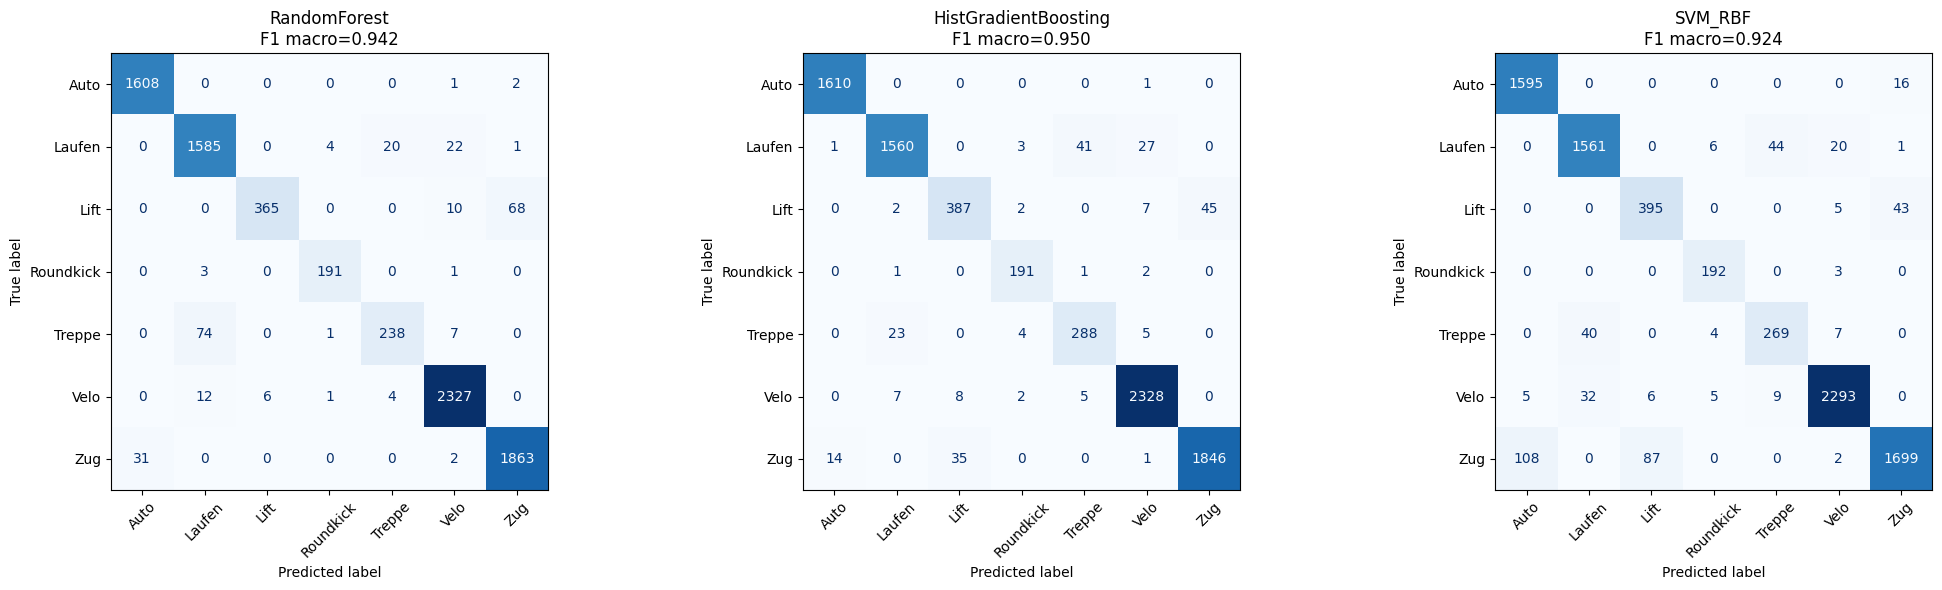

In [12]:
fig, axes = plt.subplots(1, len(results), figsize=(7 * len(results), 6))

for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test_encoded, r["y_pred"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=45)
    ax.set_title(f"{name}\nF1 macro={r['f1_macro']:.3f}")

plt.tight_layout()
plt.show()

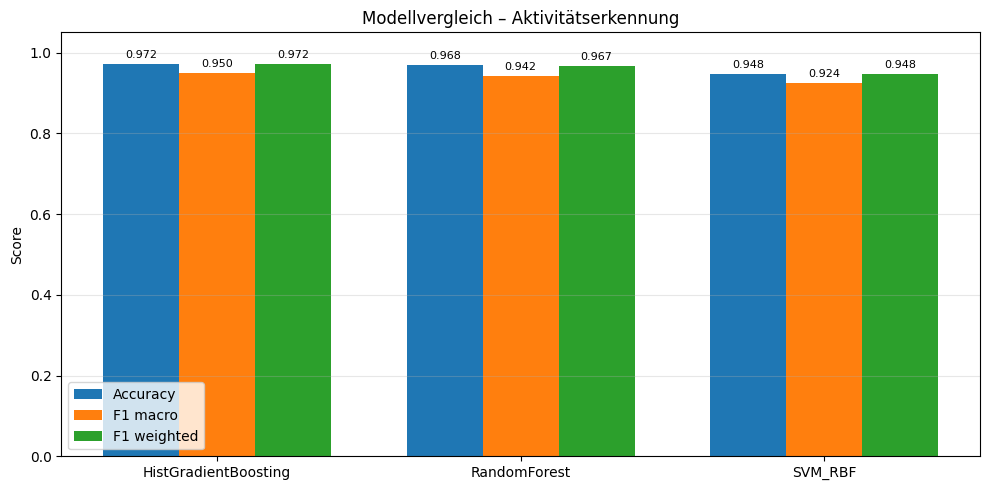

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))

x_pos = np.arange(len(summary))
bar_width = 0.25

ax.bar(x_pos - bar_width, summary["Accuracy"], bar_width, label="Accuracy")
ax.bar(x_pos, summary["F1 macro"], bar_width, label="F1 macro")
ax.bar(x_pos + bar_width, summary["F1 weighted"], bar_width, label="F1 weighted")

ax.set_xticks(x_pos)
ax.set_xticklabels(summary.index)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Modellvergleich – Aktivitätserkennung")
ax.legend()
ax.grid(axis="y", alpha=0.3)

for i, col in enumerate(["Accuracy", "F1 macro", "F1 weighted"]):
    for j, val in enumerate(summary[col]):
        ax.text(j + (i - 1) * bar_width, val + 0.01, f"{val:.3f}",
                ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

#### Analyse der Plots
- HistGradientBoosting hat den besten F1 macro (0.950) – besonders ausgewogen über alle Klassen
- RandomForest hat die höchste Accuracy (0.968), aber schwächelt bei Treppe (Recall nur 74%)
- SVM ist der schwächste der drei, besonders bei Treppe und Lift

Genau wie erwartet sind Treppe, Lift und Roundkick die schwierigsten Klassen – das waren die mit den wenigsten Daten.